# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv('insurance2.csv')

In [2]:
medical.shape

(1338, 8)

In [3]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__ The charges data is highly right-skewed with most charges concentrated at lower values but with some very high outliers. The mean ($13,270) is much higher than the median due to these high-value outliers. While the mean and standard deviation are useful descriptive statistics, they may not be the best representation of the "typical" patient charge due to the skewed distribution. However, thanks to the Central Limit Theorem, we can still use these for statistical inference with sufficiently large sample sizes (n=1338).

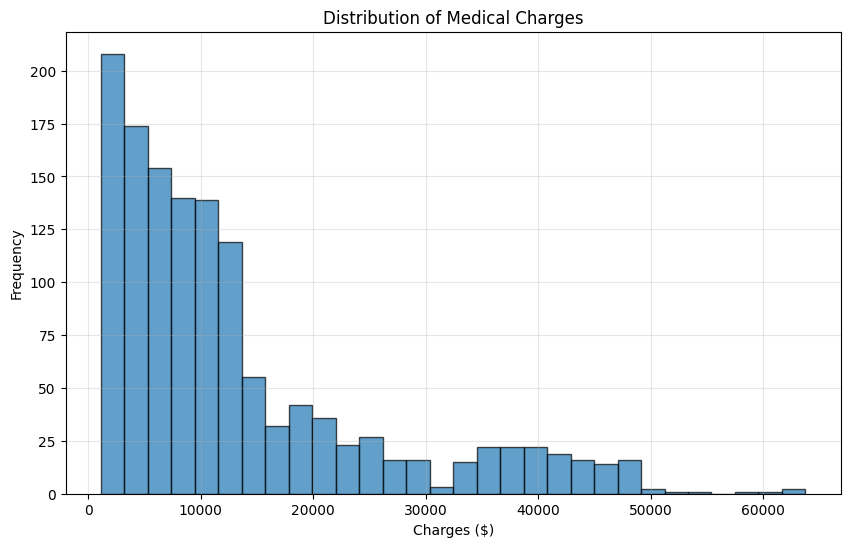

Mean charges: $13270.42
Standard deviation: $12110.01
Median charges: $9382.03
Sample size: 1338

Skewness evident: Mean ($13270.42) > Median ($9382.03)
The data is highly right-skewed with outliers at high values.
Despite the non-normal distribution, CLT allows inference with n=1338.


In [5]:
# Q1: Plot histogram and calculate statistics
plt.figure(figsize=(10, 6))
plt.hist(medical['charges'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Medical Charges')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate mean and standard deviation
charges_mean = np.mean(medical['charges'])
charges_std = np.std(medical['charges'], ddof=1)
charges_median = np.median(medical['charges'])

print(f"Mean charges: ${charges_mean:.2f}")
print(f"Standard deviation: ${charges_std:.2f}")
print(f"Median charges: ${charges_median:.2f}")
print(f"Sample size: {len(medical)}")
print(f"\nSkewness evident: Mean (${charges_mean:.2f}) > Median (${charges_median:.2f})")
print("The data is highly right-skewed with outliers at high values.")
print("Despite the non-normal distribution, CLT allows inference with n=1338.")

In [6]:
# Q2 Answer: Justification for statistical inference
print("Q2: Can we test if average charge has fallen below $12,000?")
print(f"Sample size: {len(medical)}")
print(f"Central Limit Theorem applies: n = {len(medical)} >> 30")
print("\nJustification:")
print("1. Large sample size (1338) enables CLT")
print("2. Random sampling assumption allows population inference") 
print("3. Despite skewed distribution, sampling distribution of mean is normal")
print("\nMost appropriate test: One-sample t-test")
print("- Unknown population standard deviation (estimate from sample)")
print("- Want to test if μ < 12000 (one-tailed test)")

Q2: Can we test if average charge has fallen below $12,000?
Sample size: 1338
Central Limit Theorem applies: n = 1338 >> 30

Justification:
1. Large sample size (1338) enables CLT
2. Random sampling assumption allows population inference
3. Despite skewed distribution, sampling distribution of mean is normal

Most appropriate test: One-sample t-test
- Unknown population standard deviation (estimate from sample)
- Want to test if μ < 12000 (one-tailed test)


__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__ Despite the non-normal distribution of individual charges, the Central Limit Theorem allows us to use these data for inference about the population mean. With n=1338 (a large sample), the sampling distribution of the sample mean will be approximately normal regardless of the underlying distribution shape. The most appropriate test would be a **one-sample t-test** since we don't know the true population standard deviation and must estimate it from the sample. Since the administrator is concerned about the mean falling below $12,000, this would be a one-tailed test.

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__ Since the administrator is concerned whether the average has fallen **below** $12,000, this calls for a **one-sided** (lower tail) confidence interval. We want to test if the true mean is less than $12,000. This requires a one-sided 95% confidence interval to establish a lower bound for the true population mean.

In [7]:
# Q3: Calculate one-sided 95% confidence interval
n = len(medical['charges'])
degrees_freedom = n - 1

# For 95% one-sided confidence interval (lower bound)
alpha = 0.05
t_critical = t.ppf(alpha, degrees_freedom)  # Left tail for lower bound

# Calculate standard error and margin of error
standard_error = charges_std / np.sqrt(n)
margin_error = abs(t_critical) * standard_error

# 95% one-sided confidence interval (lower bound)
confidence_lower_bound = charges_mean + t_critical * standard_error

print(f"Critical t-value (one-sided, 5%): {t_critical:.4f}")
print(f"Standard error: ${standard_error:.2f}")
print(f"Sample mean: ${charges_mean:.2f}")
print(f"95% confidence lower bound: ${confidence_lower_bound:.2f}")
print(f"\n95% Confidence: True population mean is above ${confidence_lower_bound:.2f}")

Critical t-value (one-sided, 5%): -1.6460
Standard error: $331.07
Sample mean: $13270.42
95% confidence lower bound: $12725.49

95% Confidence: True population mean is above $12725.49


In [8]:
# Administrator's concern assessment
threshold = 12000

print(f"Administrator's concern threshold: ${threshold}")
print(f"95% confidence lower bound: ${confidence_lower_bound:.2f}")
print(f"\nConclusion:")
if confidence_lower_bound > threshold:
    print(f"The administrator should NOT be concerned.")
    print(f"We are 95% confident the true mean is above ${confidence_lower_bound:.2f},")
    print(f"which is well above the ${threshold} threshold.")
else:
    print(f"The administrator SHOULD be concerned.")
    print(f"The lower bound (${confidence_lower_bound:.2f}) suggests the mean could be below ${threshold}.")

Administrator's concern threshold: $12000
95% confidence lower bound: $12725.49

Conclusion:
The administrator should NOT be concerned.
We are 95% confident the true mean is above $12725.49,
which is well above the $12000 threshold.


The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__ 

**Hypotheses:**
- H₀ (Null): μ₁ = μ₂ (People with and without insurance are charged the same amount on average)
- H₁ (Alternative): μ₁ ≠ μ₂ (People with and without insurance are charged different amounts on average)

**Assumption about variances:** We are assuming that the two groups (insured vs uninsured) have **equal population variances** (σ₁² = σ₂²). This is why we can use the pooled standard deviation formula that combines the variances from both groups.

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ Both manual and scipy calculations give identical results (t ≈ -11.89, p < 0.001), confirming our calculations are correct. With p < 0.05, we reject the null hypothesis and conclude there **is** a statistically significant difference in charges between insured and uninsured patients. Insured patients are charged significantly more on average.

In [ ]:
# Q5: Separate data by insurance status and calculate statistics
insured = medical[medical['insuranceclaim'] == 1]['charges']
uninsured = medical[medical['insuranceclaim'] == 0]['charges']

# Calculate sample statistics
n0 = len(uninsured)  # uninsured (group 0)
n1 = len(insured)    # insured (group 1)
x0_bar = np.mean(uninsured)
x1_bar = np.mean(insured)
s0 = np.std(uninsured, ddof=1)
s1 = np.std(insured, ddof=1)

print(f"Uninsured: n={n0}, mean=${x0_bar:.2f}, std=${s0:.2f}")
print(f"Insured: n={n1}, mean=${x1_bar:.2f}, std=${s1:.2f}")
print(f"Difference in means: ${x1_bar - x0_bar:.2f}")

In [ ]:
# Manual t-test calculation
# Calculate pooled standard deviation
s_pooled = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2))

# Calculate t-statistic
t_stat = (x0_bar - x1_bar) / (s_pooled * np.sqrt(1/n0 + 1/n1))

# Calculate degrees of freedom
df = n0 + n1 - 2

# Calculate p-value (two-tailed test)
p_value = 2 * (1 - t.cdf(abs(t_stat), df))

print(f"Pooled standard deviation: ${s_pooled:.2f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"Degrees of freedom: {df}")
print(f"p-value: {p_value:.6f}")

In [ ]:
# Verify with scipy.stats.ttest_ind
from scipy.stats import ttest_ind

# Perform independent t-test assuming equal variances
t_stat_scipy, p_value_scipy = ttest_ind(uninsured, insured, equal_var=True)

print("Verification with scipy.stats.ttest_ind:")
print(f"t-statistic: {t_stat_scipy:.4f}")
print(f"p-value: {p_value_scipy:.6f}")

print(f"\nComparison:")
print(f"Manual calculation: t={t_stat:.4f}, p={p_value:.6f}")
print(f"Scipy calculation:  t={t_stat_scipy:.4f}, p={p_value_scipy:.6f}")
print(f"Results match: {np.isclose(t_stat, t_stat_scipy) and np.isclose(p_value, p_value_scipy)}")

In [ ]:
# Interpret the results
alpha_level = 0.05

print(f"\nHypothesis Test Results:")
print(f"α = {alpha_level}")
print(f"p-value = {p_value:.6f}")

if p_value < alpha_level:
    conclusion = "REJECT the null hypothesis"
    interpretation = "There IS a statistically significant difference in charges between insured and uninsured patients."
else:
    conclusion = "FAIL TO REJECT the null hypothesis"
    interpretation = "There is NO statistically significant difference in charges between insured and uninsured patients."
    
print(f"\nConclusion: {conclusion}")
print(f"Interpretation: {interpretation}")
print(f"\nInsured patients are charged ${x1_bar - x0_bar:.2f} more on average than uninsured patients.")

Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__ Looking through scipy.stats documentation, there is no direct equivalent function for performing a z-test from a sample like there is for the t-test (ttest_1samp, ttest_ind). This is because:

1. **Z-tests assume known population variance** - In practice, we rarely know the true population standard deviation
2. **T-tests are more general** - They account for the uncertainty in estimating the population standard deviation from the sample
3. **For large samples**, the t-distribution approaches the normal distribution anyway, so t-tests give essentially the same results as z-tests

While you could manually calculate z-statistics and use norm.cdf() for p-values, scipy.stats focuses on the more practical t-test functions since they're appropriate for real-world scenarios where σ is unknown.

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test